# Family-Aware LLM + RAG Evaluation Summary

This notebook presents the LLM+RAG results from the frozen Checkpoint 10 head-to-head
evaluation, purely from already-saved artifacts. **No Gemini call, embedding call, or any
other API request happens anywhere in this notebook**, and no Chroma index is opened or
queried here.

**Why this notebook exists (and why it wasn't just `08_llm_rag_evaluation.ipynb` again):**
`08_llm_rag_evaluation.ipynb` is the *historical* model's LLM+RAG evaluation, run live
end-to-end in that notebook. The family-aware LLM+RAG evaluation was run once, together with
plain LLM and BERT, as part of the frozen Checkpoint 10 head-to-head evaluation across 10
robustness conditions and two vector indexes (masked/unmasked). The case-runner that made
those calls (`newstart_ai.models.llm.family_aware_evaluation.run_llm_rag_case`) has no
notebook caller committed to this repository -- only the library function, its tests, and
the artifacts it produced exist here. This notebook does not reconstruct or rerun that
evaluation; it only reads and presents the 990 already-saved case records, plus the
validation-only retrieval diagnostics that were used to freeze the retrieval configuration
before the test-set run.

**Inputs (all read-only):**
- `artifacts/family_aware/manifests/checkpoint10_pre_evaluation_freeze_v1.json` (frozen config)
- `artifacts/family_aware/reports/checkpoint10_llm_rag_predictions.jsonl` (990 row-level case records)
- `artifacts/family_aware/manifests/checkpoint10_method_condition_metrics_v1.json` (per-condition metrics)
- `artifacts/family_aware/manifests/checkpoint9_validation_retrieval_diagnostics_v1.json` (validation-only retrieval quality)
- `artifacts/family_aware/manifests/checkpoint9_diversification_effect_v1.json` (diversification before/after)
- `artifacts/family_aware/manifests/checkpoint10_cost_runtime_report_v1.json` (actual cost/runtime)

**Output:** tables and figures only -- no new prediction, metric, or model artifact is written.

## Setup

Load the frozen configuration record and the per-condition metrics manifest.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

project_root = Path("..").resolve()
manifests = project_root / "artifacts" / "family_aware" / "manifests"
reports = project_root / "artifacts" / "family_aware" / "reports"

with open(manifests / "checkpoint10_pre_evaluation_freeze_v1.json", encoding="utf-8") as f:
    freeze = json.load(f)

with open(manifests / "checkpoint10_method_condition_metrics_v1.json", encoding="utf-8") as f:
    all_metrics = json.load(f)

CONDITION_ORDER = [
    "complete_unmasked", "beginning_only_unmasked", "middle_only_unmasked", "end_only_unmasked",
    "beginning_middle_end_unmasked", "complete_masked", "beginning_only_masked", "middle_only_masked",
    "end_only_masked", "beginning_middle_end_masked",
]

## Frozen configuration

Same LLM settings as the plain-LLM notebook, plus the retrieval-specific settings that were
fixed before the first Gemini classification request was made.

In [2]:
print(f"Model: {freeze['llm_model_name']}  (temperature {freeze['generation_temperature']})")
print(f"RAG prompt version: {freeze['rag_prompt_version']}  (hash {freeze['rag_prompt_hash'][:16]}...)")
print(f"Embedding model: {freeze['rag_embedding_model']}")
print(f"Candidate pool size: {freeze['retrieval_candidate_pool_size']}   top_k: {freeze['retrieval_top_k']}")
print(f"Max chunks per parent document: {freeze['retrieval_max_chunks_per_parent_document']}")
print(f"Max results per effective family: {freeze['retrieval_max_results_per_effective_family']}")
print(f"Tie breaker: {freeze['retrieval_tie_breaker']}")
print(f"Unmasked corpus fingerprint: {freeze['rag_unmasked_corpus_fingerprint'][:16]}...")
print(f"Masked corpus fingerprint:   {freeze['rag_masked_corpus_fingerprint'][:16]}...")

Model: gemini-3.6-flash  (temperature 0.0)
RAG prompt version: family_aware_v1  (hash 726cafbfc0a462e3...)
Embedding model: gemini-embedding-001
Candidate pool size: 20   top_k: 5
Max chunks per parent document: 2
Max results per effective family: 2
Tie breaker: higher_similarity_then_deterministic_chunk_id_hash
Unmasked corpus fingerprint: 4c964c57adf27cac...
Masked corpus fingerprint:   a97a4d859dbdf2ed...


## Retrieval quality (validation-only diagnostics)

This is the diagnostic evidence used to confirm the retrieval configuration *before* it was
frozen and applied to the test set -- never computed from test data.

In [3]:
with open(manifests / "checkpoint9_validation_retrieval_diagnostics_v1.json", encoding="utf-8") as f:
    retrieval_diag = json.load(f)

diag_rows = [
    {"condition": r["condition"], "index_used": r["index_used"], "query_document_count": r["query_document_count"],
     "top_k_agency_hit_rate": r["top_k_agency_hit_rate"], "mean_reciprocal_rank": r["mean_reciprocal_rank"],
     "mean_similarity": r["mean_similarity"]}
    for r in retrieval_diag["results"]
]
pd.DataFrame(diag_rows).set_index("condition").loc[CONDITION_ORDER]

,index_used,query_document_count,top_k_agency_hit_rate,mean_reciprocal_rank,mean_similarity
condition,,,,,
complete_unmasked,unmasked,99,100.00,0.9949,0.8128
beginning_only_unmasked,unmasked,99,100.00,1.0000,0.7941
middle_only_unmasked,unmasked,99,100.00,1.0000,0.8131
end_only_unmasked,unmasked,99,100.00,1.0000,0.8232
beginning_middle_end_unmasked,unmasked,99,100.00,1.0000,0.8265
complete_masked,masked,99,100.00,0.9933,0.8277
beginning_only_masked,masked,99,100.00,1.0000,0.8025
middle_only_masked,masked,99,100.00,0.9933,0.8172
end_only_masked,masked,99,98.99,0.9848,0.8284


## Diversification effect

The per-parent-document and per-family caps (2 chunks max each) reduce how much the
retrieved context is dominated by a single document or family, at the cost of occasionally
returning fewer than `top_k` results.

In [4]:
with open(manifests / "checkpoint9_diversification_effect_v1.json", encoding="utf-8") as f:
    diversification = json.load(f)

print(f"Sample size: {diversification['sample_size']} queries")
print(f"Mean top-parent-document share: {diversification['mean_top_parent_share_before']:.4f} -> "
      f"{diversification['mean_top_parent_share_after']:.4f} (before -> after diversification)")
print(f"Mean top-family share: {diversification['mean_top_family_share_before']:.4f} -> "
      f"{diversification['mean_top_family_share_after']:.4f} (before -> after diversification)")
print(f"Document 739 (the 519-chunk outlier) max top-5 positions: "
      f"{diversification['document_739_max_positions_before']} -> {diversification['document_739_max_positions_after']}")

Sample size: 99 queries
Mean top-parent-document share: 0.5273 -> 0.3838 (before -> after diversification)
Mean top-family share: 0.5879 -> 0.3980 (before -> after diversification)
Document 739 (the 519-chunk outlier) max top-5 positions: 1 -> 2


## Load the 990 row-level case records

In [5]:
predictions = pd.read_json(reports / "checkpoint10_llm_rag_predictions.jsonl", lines=True)
predictions["correct"] = predictions["predicted_label"] == predictions["true_label"]
print(f"Total cases: {len(predictions)}")
predictions["status"].value_counts()

Total cases: 990


status
success    990
Name: count, dtype: int64

## Masked/unmasked index routing check

A masked condition's query must only ever retrieve chunks from the masked index (and an
unmasked condition only from the unmasked index) -- never a mix. This is re-derived directly
from the row-level `retrieved_chunks` provenance, independent of the integrity manifest's
own `masked_queries_used_masked_index_only` flag.

In [6]:
exploded = predictions.explode("retrieved_chunks").dropna(subset=["retrieved_chunks"])
exploded["chunk_masked"] = exploded["retrieved_chunks"].apply(lambda c: c["masked"])
exploded["condition_masked"] = exploded["condition"].str.endswith("_masked")

mismatches = exploded[exploded["chunk_masked"] != exploded["condition_masked"]]
print(f"Retrieved-chunk rows checked: {len(exploded)}")
print(f"Rows where retrieved chunk's masked flag does not match the query condition: {len(mismatches)}")

Retrieved-chunk rows checked: 4907
Rows where retrieved chunk's masked flag does not match the query condition: 0


## Example retrieved context (one case)

The retrieved-chunk *provenance* recorded for evaluation logging (chunk id, similarity,
parent document, agency) -- **not** what the LLM prompt itself saw. The prompt only ever
received chunk text with no labels or IDs attached (`format_context_no_labels`); this
provenance is reconstructed here purely for analysis.

In [7]:
example = predictions[(predictions["document_id"] == 3) & (predictions["condition"] == "complete_unmasked")].iloc[0]
pd.DataFrame(example["retrieved_chunks"])[["rank", "similarity", "parent_document_id", "effective_family_id", "effective_agency", "masked"]]

,rank,similarity,parent_document_id,effective_family_id,effective_agency,masked
0,1,0.829292,4,USCIS:G1566,USCIS,False
1,2,0.817573,161,USCIS:I905,USCIS,False
2,3,0.817527,190,USCIS:N600,USCIS,False
3,4,0.815330,67,USCIS:I539,USCIS,False
4,5,0.814310,114,USCIS:I360,USCIS,False


## Per-condition metrics

Sourced directly from the frozen Checkpoint 10 metrics manifest (not recomputed here).

In [8]:
rag_metrics = pd.DataFrame([m for m in all_metrics if m["method"] == "llm_rag"])
rag_metrics = rag_metrics.set_index("condition").loc[CONDITION_ORDER].reset_index()
rag_metrics[["condition", "document_count", "document_accuracy", "document_macro_f1",
             "macro_precision", "macro_recall", "error_count", "coverage_rate"]]

,condition,document_count,document_accuracy,document_macro_f1,macro_precision,macro_recall,error_count,coverage_rate
0,complete_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
1,beginning_only_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
2,middle_only_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
3,end_only_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
4,beginning_middle_end_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
5,complete_masked,99,1.0,1.0,1.0,1.0,0,100.0
6,beginning_only_masked,99,1.0,1.0,1.0,1.0,0,100.0
7,middle_only_masked,99,1.0,1.0,1.0,1.0,0,100.0
8,end_only_masked,99,1.0,1.0,1.0,1.0,0,100.0
9,beginning_middle_end_masked,99,1.0,1.0,1.0,1.0,0,100.0


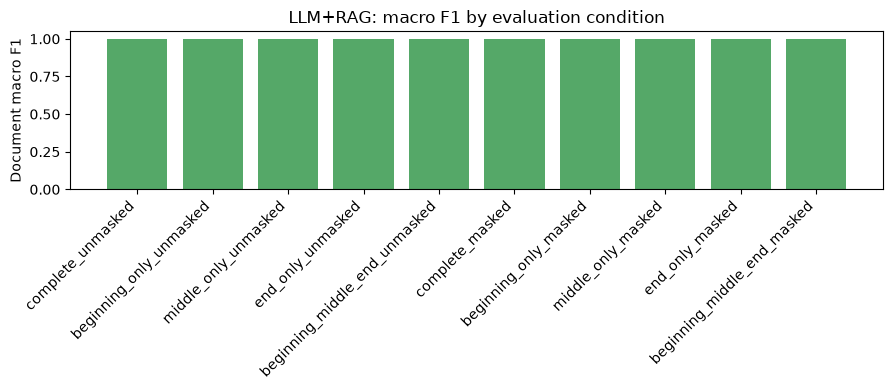

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(rag_metrics["condition"], rag_metrics["document_macro_f1"], color="#55A868")
ax.set_ylabel("Document macro F1")
ax.set_title("LLM+RAG: macro F1 by evaluation condition")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Confusion matrix -- primary condition (`complete_unmasked`)

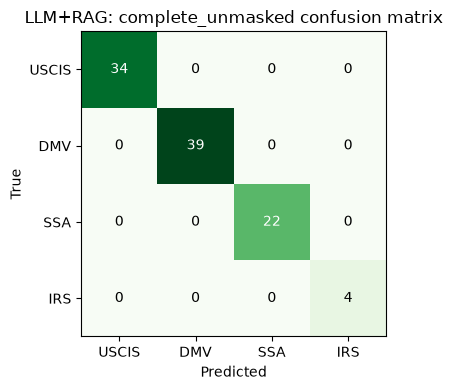

In [10]:
primary = next(m for m in all_metrics if m["method"] == "llm_rag" and m["condition"] == "complete_unmasked")
labels = freeze["label_order"]
# confusion_matrix is stored as {true_label: {predicted_label: count}} -- pd.DataFrame() on a
# dict-of-dicts puts the outer key (true label) on columns, so transpose to get the
# conventional rows=true / columns=predicted orientation before reindexing.
cm = pd.DataFrame(primary["confusion_matrix"]).T.reindex(index=labels, columns=labels).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm.values, cmap="Greens")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("LLM+RAG: complete_unmasked confusion matrix")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm.values[i, j], ha="center", va="center",
                color="white" if cm.values[i, j] > cm.values.max() / 2 else "black")
plt.tight_layout()
plt.show()

## Misclassified cases

In [11]:
errors = predictions.loc[~predictions["correct"], ["document_id", "condition", "true_label", "predicted_label", "truncated"]]
print(f"{len(errors)} misclassified case(s) out of {len(predictions)}")
errors.reset_index(drop=True)

0 misclassified case(s) out of 990


,document_id,condition,true_label,predicted_label,truncated


## Cost and latency

In [12]:
print(f"Total tokens billed: {int(predictions['total_tokens'].sum()):,}")
print(f"Total estimated cost: ${predictions['estimated_cost_usd'].sum():.4f}")
print()
print("Latency (ms):")
predictions["latency_ms"].describe()[["mean", "50%", "min", "max"]].rename({"50%": "median"})

Total tokens billed: 3,792,770
Total estimated cost: $0.4310

Latency (ms):


mean      1783.060894
median    1707.829350
min        986.290000
max       9268.404300
Name: latency_ms, dtype: float64

## Comparison against plain LLM

A quick, side-by-side macro F1 pull from the same frozen metrics manifest used in the plain-
LLM notebook -- the full statistical comparison (paired significance testing) lives in
Notebook 11, not repeated here.

In [13]:
llm_f1 = pd.DataFrame([m for m in all_metrics if m["method"] == "llm"]).set_index("condition")["document_macro_f1"]
rag_f1 = pd.DataFrame([m for m in all_metrics if m["method"] == "llm_rag"]).set_index("condition")["document_macro_f1"]
pd.DataFrame({"plain_llm_macro_f1": llm_f1, "llm_rag_macro_f1": rag_f1}).loc[CONDITION_ORDER]

,plain_llm_macro_f1,llm_rag_macro_f1
condition,,
complete_unmasked,1.0,1.0
beginning_only_unmasked,1.0,1.0
middle_only_unmasked,1.0,1.0
end_only_unmasked,1.0,1.0
beginning_middle_end_unmasked,1.0,1.0
complete_masked,1.0,1.0
beginning_only_masked,1.0,1.0
middle_only_masked,1.0,1.0
end_only_masked,1.0,1.0


## Summary

- All 990 LLM+RAG cases (99 documents x 10 conditions) completed with `status=success`.
- Retrieval quality was confirmed on validation data before the test run: 100% top-5 agency
  hit rate across all 10 conditions, with diversification reducing the average share any
  single parent document or family occupies among retrieved chunks.
- Every retrieved chunk's masked flag matched its query condition's masked flag -- confirmed
  directly from row-level provenance, not just the saved integrity manifest.
- This notebook is read-only with respect to the frozen Checkpoint 10 evaluation: it loads
  saved manifests and produces no new prediction, metric, or model artifact.